<font color="#CA0032"><h1 align="left"><b>Entradas heterogéneas — Modelo final</b></h1></font>
<font color="#6E6E6E"><h2 align="left"><b>Predicción de ventas Rossmann · Práctica B3—T5</b></h2></font>

**Componentes del grupo:**

- Natalia
- Josep
- Emilio

Este cuaderno es **autocontenido**: parte de los CSV originales y llega hasta la predicción final
sobre `test.csv`. Reutiliza las decisiones de preprocesado del notebook del grupo
(`entradas_heterogeneas.ipynb`, secciones 2–3) de forma condensada, y el análisis exploratorio
completo está en `exploración_dataset.ipynb`.

### **Estrategia en 6 decisiones (justificación del diseño)**

| # | Decisión | Por qué |
|---|----------|---------|
| 1 | **Modelo funcional con 3 tipos de entrada**: rama recurrente (GRU) para la ventana temporal, embeddings para categóricas de tienda, rama directa para numéricas | Es la esencia de las *entradas heterogéneas*: cada naturaleza de dato recibe el tratamiento adecuado |
| 2 | **Exógenas del día objetivo** como entrada adicional (DayOfWeek, Promo, Open, StateHoliday, SchoolHoliday, estacionalidad) | Sin ellas el modelo "no sabe qué día predice"; la estacionalidad semanal y el efecto Promo (+39 %) son los factores más fuertes tras el nivel de cada tienda |
| 3 | **Entrenar solo con días abiertos y forzar `Sales=0` si `Open=0`** | `Open` ↔ ventas 0 es casi determinista (solo 54 excepciones en 1M de filas) y `Open` es conocido a futuro |
| 4 | **`log1p(Sales)` como objetivo** | La distribución de ventas está muy sesgada; en log el error se vuelve homogéneo entre tiendas grandes y pequeñas |
| 5 | **Horizonte de 14 días para el modelo final** | `train` acaba el 2015-07-17 y `test` es el 2015-07-31: el modelo debe aprender exactamente la tarea que se le pedirá en test |
| 6 | **Dos variantes finales: con y sin `Customers` del día objetivo** | `test.csv` proporciona `Customers` (correlación 0,82 con ventas), pero en un despliegue real no se conocería: presentamos ambas y discutimos el *leakage* |

**Protocolo de evaluación:** partición temporal (validación = últimas 6 semanas), métricas en escala
real de ventas (R², RMSE, MAE), y el mismo post-proceso (ceros forzados por `Open`) aplicado a
**todos** los métodos, baselines incluidos, para que la comparación sea justa.

## <font color='#CA3532'>**1. Librerías y configuración**</font>

In [1]:
import os, gc, time, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path

import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

from keras.layers import Input, GRU, LSTM, Bidirectional, Embedding, Flatten, Dense, Dropout, concatenate
from keras import Model, optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import set_random_seed

warnings.filterwarnings("ignore")
np.random.seed(7)
set_random_seed(7)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
ROJO, GRIS, AZUL = "#CA0032", "#6E6E6E", "#2E5A87"

In [2]:
# Interruptor de desarrollo: en True ejecuta una versión reducida (10 tiendas, pocas épocas)
# para validar el flujo completo antes de lanzar el entrenamiento real.
MODO_RAPIDO = False

## <font color='#CA3532'>**2. Carga y preparación de los datos**</font>

Versión condensada del preprocesado del notebook del grupo: unión con `store.csv`, variables de
calendario, limpieza de nulos con significado, variables de competencia y `Promo2`, y códigos
enteros para los embeddings (ajustados sobre la unión de `train` y `test` para que ninguna
categoría quede fuera de rango).

In [3]:
DATASET_DIR = Path("dataset_completo_Rossmann-20260604T174330Z-3-001") / "dataset_completo_Rossmann"
if not DATASET_DIR.exists():
    candidates = sorted(Path(".").glob("**/dataset_completo_Rossmann"))
    if not candidates:
        raise FileNotFoundError("No se ha encontrado la carpeta dataset_completo_Rossmann")
    DATASET_DIR = candidates[0]

train = pd.read_csv(DATASET_DIR / "train.csv", parse_dates=["Date"], low_memory=False)
test  = pd.read_csv(DATASET_DIR / "test.csv",  parse_dates=["Date"], low_memory=False)
store = pd.read_csv(DATASET_DIR / "store.csv", low_memory=False)
submission_ejemplo = pd.read_csv(DATASET_DIR / "submission.csv")

for df_ in (train, test):
    df_["StateHoliday"] = df_["StateHoliday"].astype(str).replace({"0.0": "0"})

print("train:", train.shape, "| test:", test.shape, "| store:", store.shape)

train: (1001599, 10) | test: (1115, 9) | store: (1115, 10)


In [4]:
def crear_variables_calendario(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["DayOfYear"] = df["Date"].dt.dayofyear
    return df


def limpiar_variables_tienda(df, mediana_distancia):
    df = df.copy()
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(mediana_distancia)
    df["PromoInterval"] = df["PromoInterval"].fillna("None")
    for col in ["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
                "Promo2SinceWeek", "Promo2SinceYear"]:
        df[col] = df[col].fillna(0)
    return df


def crear_variables_competencia(df):
    df = df.copy()
    hay = (df["CompetitionOpenSinceMonth"] > 0) & (df["CompetitionOpenSinceYear"] > 0)
    meses = (df["Year"] - df["CompetitionOpenSinceYear"]) * 12 + (df["Month"] - df["CompetitionOpenSinceMonth"])
    df["CompetitionOpen"] = hay.astype(int)
    df["CompetitionOpenMonths"] = meses.where(hay, 0).clip(lower=0)
    return df


MESES_PROMO = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
               7: "Jul", 8: "Aug", 9: "Sept", 10: "Oct", 11: "Nov", 12: "Dec"}


def crear_variables_promo2(df):
    # Nota: convertimos semana/año a entero ANTES de formar el código ISO; con floats
    # ("13.0") el parseo fallaría en silencio y Promo2Weeks quedaría a 0.
    df = df.copy()
    activo = (df["Promo2"] == 1) & (df["Promo2SinceWeek"] > 0) & (df["Promo2SinceYear"] > 0)
    inicio = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
    if activo.any():
        codigo_iso = (df.loc[activo, "Promo2SinceYear"].astype(int).astype(str)
                      + df.loc[activo, "Promo2SinceWeek"].astype(int).astype(str).str.zfill(2)
                      + "1")
        inicio.loc[activo] = pd.to_datetime(codigo_iso, format="%G%V%u", errors="coerce")
    semanas = (df["Date"] - inicio).dt.days / 7.0
    df["Promo2Weeks"] = semanas.fillna(0).clip(lower=0)

    mes_label = df["Month"].map(MESES_PROMO)
    en_intervalo = np.array([m in s for m, s in zip(mes_label, df["PromoInterval"].astype(str))])
    df["Promo2ActiveMonth"] = (en_intervalo & activo.to_numpy() & (df["Promo2Weeks"].to_numpy() > 0)).astype(int)
    return df


def crear_codigos(train_df, test_df, columnas):
    train_df, test_df = train_df.copy(), test_df.copy()
    cardinalidades, categorias = {}, {}
    for col in columnas:
        cats = pd.Index(
            pd.concat([train_df[col], test_df[col]], ignore_index=True).astype(str).unique()
        ).sort_values()
        mapa = {c: i for i, c in enumerate(cats)}
        train_df[f"{col}Code"] = train_df[col].astype(str).map(mapa).astype(int)
        test_df[f"{col}Code"] = test_df[col].astype(str).map(mapa).astype(int)
        cardinalidades[f"{col}Code"] = len(cats)
        categorias[col] = list(cats)
    return train_df, test_df, cardinalidades, categorias

In [5]:
mediana_distancia = store["CompetitionDistance"].median()

train_full = train.merge(store, on="Store", how="left", validate="many_to_one")
test_full  = test.merge(store, on="Store", how="left", validate="many_to_one")

for nombre in ["train_full", "test_full"]:
    df_ = crear_variables_calendario(eval(nombre))
    df_ = limpiar_variables_tienda(df_, mediana_distancia)
    df_ = crear_variables_competencia(df_)
    df_ = crear_variables_promo2(df_)
    globals()[nombre] = df_

train_full, test_full, cardinalidades, categorias = crear_codigos(
    train_full, test_full,
    ["Store", "DayOfWeek", "StateHoliday", "StoreType", "Assortment", "PromoInterval"],
)

train_full = train_full.sort_values(["Store", "Date"]).reset_index(drop=True)
test_full  = test_full.sort_values("Store").reset_index(drop=True)

print("Cardinalidades para embeddings:", cardinalidades)
print("Fechas train:", train_full["Date"].min().date(), "->", train_full["Date"].max().date())
print("Fecha test  :", test_full["Date"].min().date(),
      f"(hueco de {(test_full['Date'].min() - train_full['Date'].max()).days} días tras el final de train)")
display(train_full[["Store", "Date", "Sales", "Open", "Promo", "Promo2Weeks",
                    "Promo2ActiveMonth", "CompetitionOpenMonths", "StoreCode", "DayOfWeekCode"]].head())

Cardinalidades para embeddings: {'StoreCode': 1115, 'DayOfWeekCode': 7, 'StateHolidayCode': 4, 'StoreTypeCode': 4, 'AssortmentCode': 3, 'PromoIntervalCode': 4}
Fechas train: 2013-01-01 -> 2015-07-17
Fecha test  : 2015-07-31 (hueco de 14 días tras el final de train)


,Store,Date,Sales,Open,Promo,Promo2Weeks,Promo2ActiveMonth,CompetitionOpenMonths,StoreCode,DayOfWeekCode
0,1,2013-01-01,0,0,0,0.000,0,52.000,0,1
1,1,2013-01-02,5530,1,0,0.000,0,52.000,0,2
2,1,2013-01-03,4327,1,0,0.000,0,52.000,0,3
3,1,2013-01-04,4486,1,0,0.000,0,52.000,0,4
4,1,2013-01-05,4997,1,0,0.000,0,52.000,0,5


## <font color='#CA3532'>**3. Enventanado temporal eficiente**</font>

Cada muestra contiene los últimos `lookback = 28` días de una tienda y predice las ventas del día
situado `horizonte` días después del final de la ventana. Se generan tres bloques por muestra:

- **`Xt`** `(n, 28, 13)`: ventana temporal (las mismas 13 variables que el notebook del grupo).
- **`Xe`** `(n, 7)`: atributos estáticos de tienda (4 códigos para embeddings + 3 numéricas).
- **`Xo`** `(n, 8)`: **exógenas del día objetivo** — códigos de `DayOfWeek` y `StateHoliday`,
  binarias `Promo`/`Open`/`SchoolHoliday`, estacionalidad anual (`sin`/`cos` del día del año) y
  `Customers` (solo la usará la variante M4).

Implementado con `sliding_window_view` (vectorizado, necesario para ~1 M de ventanas). Las
ventanas que atraviesan **huecos de fechas** (≈180 tiendas cerradas unos meses en 2014) se
**descartan** comprobando que cada ventana abarca exactamente los días naturales esperados.

In [6]:
COLS_TEMPORALES = [
    "Sales", "Customers", "Open", "Promo", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpenMonths",
    "Promo2Weeks", "Promo2ActiveMonth",
    "DayOfWeek", "Month", "WeekOfYear", "DayOfYear",
]
COLS_ESTATICAS = [
    "StoreCode", "StoreTypeCode", "AssortmentCode", "PromoIntervalCode",
    "CompetitionDistance", "CompetitionOpen", "Promo2",
]
COLS_OBJETIVO_BASE = [
    "DayOfWeekCode", "StateHolidayCode", "Promo", "Open", "SchoolHoliday", "DayOfYear", "Customers",
]

IDX_SALES_T = COLS_TEMPORALES.index("Sales")
LOOKBACK = 28


def construir_ventanas(df, lookback=28, horizonte=1, tiendas=None):
    if tiendas is not None:
        df = df[df["Store"].isin(tiendas)]
    df = df.sort_values(["Store", "Date"])

    span_esperado = np.timedelta64(lookback - 1 + horizonte, "D")
    Xt_l, Xe_l, Xo_l, y_l, open_l, store_l, fecha_l = [], [], [], [], [], [], []
    descartadas = 0

    for store_id, g in df.groupby("Store", sort=True):
        n = len(g)
        k = n - lookback - horizonte + 1
        if k <= 0:
            continue
        arr_t = g[COLS_TEMPORALES].to_numpy(np.float32)
        arr_e = g[COLS_ESTATICAS].to_numpy(np.float32)
        arr_o = g[COLS_OBJETIVO_BASE].to_numpy(np.float32)
        fechas = g["Date"].to_numpy()

        ventanas = sliding_window_view(arr_t, lookback, axis=0).transpose(0, 2, 1)[:k]
        idx_obj = np.arange(lookback + horizonte - 1, n)

        ok = (fechas[idx_obj] - fechas[:k]) == span_esperado
        descartadas += int((~ok).sum())
        if not ok.any():
            continue

        doy = arr_o[idx_obj, 5]
        xo = np.column_stack([
            arr_o[idx_obj, 0], arr_o[idx_obj, 1],
            arr_o[idx_obj, 2], arr_o[idx_obj, 3], arr_o[idx_obj, 4],
            np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25),
            arr_o[idx_obj, 6],
        ]).astype(np.float32)

        Xt_l.append(ventanas[ok])
        Xe_l.append(arr_e[idx_obj][ok])
        Xo_l.append(xo[ok])
        y_l.append(arr_t[idx_obj, IDX_SALES_T][ok])
        open_l.append(arr_o[idx_obj, 3][ok])
        store_l.append(np.full(int(ok.sum()), store_id, dtype=np.int32))
        fecha_l.append(fechas[idx_obj][ok])

    return {
        "Xt": np.concatenate(Xt_l), "Xe": np.concatenate(Xe_l), "Xo": np.concatenate(Xo_l),
        "y": np.concatenate(y_l), "open": np.concatenate(open_l),
        "meta": pd.DataFrame({
            "Store": np.concatenate(store_l),
            "DateObjetivo": pd.to_datetime(np.concatenate(fecha_l)),
        }),
        "descartadas": descartadas,
    }

## <font color='#CA3532'>**4. Escalado, modelo parametrizado y protocolo de evaluación**</font>

- `log1p` en `Sales`, `Customers` y `CompetitionDistance` (muy sesgadas) y estandarización de las
  continuas, con estadísticos ajustados **solo en el conjunto de entrenamiento**.
- `crear_modelo` construye cualquier variante (densa/GRU/LSTM, con/sin embeddings, con/sin día
  objetivo, con/sin `Customers`): toda la comparación de arquitecturas usa el mismo código.
- `predecir_real` invierte el `log1p` y aplica el post-proceso de **ceros forzados** (`Open=0 →
  Sales=0`); las métricas se calculan en escala real, en total y solo sobre días abiertos.

In [7]:
IDX_LOG_T  = [COLS_TEMPORALES.index(c) for c in ["Sales", "Customers", "CompetitionDistance"]]
IDX_BIN_T  = {COLS_TEMPORALES.index(c) for c in ["Open", "Promo", "SchoolHoliday", "Promo2ActiveMonth"]}
IDX_CONT_T = [i for i in range(len(COLS_TEMPORALES)) if i not in IDX_BIN_T]
IDX_DIST_E = COLS_ESTATICAS.index("CompetitionDistance")
IDX_CUST_O = 7


def ajustar_y_escalar(V, mask_ajuste):
    # Escala in-place los arrays de V; estadísticos solo de mask_ajuste. Devuelve los parámetros.
    Xt, Xe, Xo = V["Xt"], V["Xe"], V["Xo"]
    params = {"t": {}, "e": None, "o": None}
    for i in IDX_LOG_T:
        np.log1p(np.maximum(Xt[:, :, i], 0), out=Xt[:, :, i])
    for i in IDX_CONT_T:
        v = Xt[mask_ajuste, :, i]
        mu, sd = float(v.mean()), float(v.std() + 1e-8)
        Xt[:, :, i] -= mu
        Xt[:, :, i] /= sd
        params["t"][i] = (mu, sd)
    np.log1p(np.maximum(Xe[:, IDX_DIST_E], 0), out=Xe[:, IDX_DIST_E])
    mu, sd = float(Xe[mask_ajuste, IDX_DIST_E].mean()), float(Xe[mask_ajuste, IDX_DIST_E].std() + 1e-8)
    Xe[:, IDX_DIST_E] = (Xe[:, IDX_DIST_E] - mu) / sd
    params["e"] = (mu, sd)
    np.log1p(np.maximum(Xo[:, IDX_CUST_O], 0), out=Xo[:, IDX_CUST_O])
    mu, sd = float(Xo[mask_ajuste, IDX_CUST_O].mean()), float(Xo[mask_ajuste, IDX_CUST_O].std() + 1e-8)
    Xo[:, IDX_CUST_O] = (Xo[:, IDX_CUST_O] - mu) / sd
    params["o"] = (mu, sd)
    return params


def aplicar_escalado(params, Xt, Xe, Xo):
    # Aplica a arrays nuevos (test) el escalado ajustado en entrenamiento.
    for i in IDX_LOG_T:
        np.log1p(np.maximum(Xt[:, :, i], 0), out=Xt[:, :, i])
    for i, (mu, sd) in params["t"].items():
        Xt[:, :, i] = (Xt[:, :, i] - mu) / sd
    np.log1p(np.maximum(Xe[:, IDX_DIST_E], 0), out=Xe[:, IDX_DIST_E])
    mu, sd = params["e"]
    Xe[:, IDX_DIST_E] = (Xe[:, IDX_DIST_E] - mu) / sd
    np.log1p(np.maximum(Xo[:, IDX_CUST_O], 0), out=Xo[:, IDX_CUST_O])
    mu, sd = params["o"]
    Xo[:, IDX_CUST_O] = (Xo[:, IDX_CUST_O] - mu) / sd


def preparar_datos(V, dias_validacion=42):
    # Partición temporal + escalado. Entrenamiento solo con días abiertos (decisión 3).
    fecha_corte = V["meta"]["DateObjetivo"].max() - pd.Timedelta(days=dias_validacion)
    mask_tr = (V["meta"]["DateObjetivo"] <= fecha_corte).to_numpy()
    mask_va = ~mask_tr
    abiertos = V["open"] > 0
    mask_fit = mask_tr & abiertos
    mask_vo  = mask_va & abiertos

    params = ajustar_y_escalar(V, mask_fit)

    D = {
        "lookback": V["Xt"].shape[1], "params": params, "fecha_corte": fecha_corte,
        "Xt_fit": V["Xt"][mask_fit], "Xe_fit": V["Xe"][mask_fit], "Xo_fit": V["Xo"][mask_fit],
        "y_fit_log": np.log1p(V["y"][mask_fit]),
        "Xt_vo": V["Xt"][mask_vo], "Xe_vo": V["Xe"][mask_vo], "Xo_vo": V["Xo"][mask_vo],
        "y_vo_log": np.log1p(V["y"][mask_vo]),
        "Xt_val": V["Xt"][mask_va], "Xe_val": V["Xe"][mask_va], "Xo_val": V["Xo"][mask_va],
        "y_val": V["y"][mask_va], "open_val": V["open"][mask_va],
        "meta_val": V["meta"].loc[mask_va].reset_index(drop=True),
    }
    for arr in [D["Xt_fit"], D["Xo_fit"], D["Xt_val"], D["Xo_val"]]:
        assert np.isfinite(arr).all(), "Hay valores no finitos tras el escalado"
    print(f"corte train/val: {fecha_corte.date()} | fit (abiertos): {len(D['y_fit_log']):,} "
          f"| val (completa): {len(D['y_val']):,}")
    return D

In [8]:
def crear_modelo(lookback, rama="gru", unidades=32, capas_rnn=None, bidireccional=False,
                 densas=(64, 32), dropouts=(0.2, 0.0),
                 solo_endogena=False, usar_estaticas=True, usar_dia_objetivo=False,
                 usar_customers=False, dim_emb_store=16, lr=1e-3):
    set_random_seed(7)
    if capas_rnn is None:
        capas_rnn = (unidades,)          # compatibilidad: una sola capa de tamaño `unidades`
    n_feat = 1 if solo_endogena else len(COLS_TEMPORALES)
    in_temporal = Input(shape=(lookback, n_feat), name="temporal")
    if rama == "densa":                  # referencia sin recurrencia
        r = Dense(capas_rnn[0], activation="relu")(Flatten()(in_temporal))
    else:                                # GRU o LSTM, posiblemente apiladas/bidireccionales
        RNN = GRU if rama == "gru" else LSTM
        x = in_temporal
        for i, u in enumerate(capas_rnn):
            capa = RNN(u, return_sequences=(i < len(capas_rnn) - 1),
                       name="rnn" if len(capas_rnn) == 1 else f"rnn{i}")
            x = (Bidirectional(capa) if bidireccional else capa)(x)
        r = x
    entradas, ramas = [in_temporal], [r]

    if usar_estaticas:
        for nombre, col, dim in [("store", "StoreCode", dim_emb_store),
                                 ("storetype", "StoreTypeCode", 2),
                                 ("assortment", "AssortmentCode", 2),
                                 ("promointerval", "PromoIntervalCode", 2)]:
            inp = Input(shape=(1,), name=nombre)
            entradas.append(inp)
            ramas.append(Flatten()(Embedding(cardinalidades[col], dim, name=f"emb_{nombre}")(inp)))
        in_numerico = Input(shape=(3,), name="numerico")
        entradas.append(in_numerico)
        ramas.append(in_numerico)

    if usar_dia_objetivo:
        in_dow = Input(shape=(1,), name="dow_obj")
        entradas.append(in_dow)
        ramas.append(Flatten()(Embedding(cardinalidades["DayOfWeekCode"], 3, name="emb_dow_obj")(in_dow)))
        in_festivo = Input(shape=(1,), name="festivo_obj")
        entradas.append(in_festivo)
        ramas.append(Flatten()(Embedding(cardinalidades["StateHolidayCode"], 2, name="emb_festivo_obj")(in_festivo)))
        in_exog = Input(shape=(5,), name="exog_obj")
        entradas.append(in_exog)
        ramas.append(in_exog)

    if usar_customers:
        in_customers = Input(shape=(1,), name="customers_obj")
        entradas.append(in_customers)
        ramas.append(in_customers)

    x = concatenate(ramas) if len(ramas) > 1 else ramas[0]
    for u, dr in zip(densas, dropouts):
        x = Dense(u, activation="relu")(x)
        if dr > 0:
            x = Dropout(dr)(x)
    salida = Dense(1, name="sales_log")(x)

    modelo = Model(inputs=entradas, outputs=salida)
    modelo.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr), metrics=["mae"])
    return modelo


def construir_xs(Xt, Xe, Xo, solo_endogena=False, usar_estaticas=True,
                 usar_dia_objetivo=False, usar_customers=False, **_):
    d = {"temporal": Xt[:, :, [IDX_SALES_T]] if solo_endogena else Xt}
    if usar_estaticas:
        for j, nombre in enumerate(["store", "storetype", "assortment", "promointerval"]):
            d[nombre] = Xe[:, j:j + 1].astype("int32")
        d["numerico"] = Xe[:, 4:7].astype("float32")
    if usar_dia_objetivo:
        d["dow_obj"] = Xo[:, 0:1].astype("int32")
        d["festivo_obj"] = Xo[:, 1:2].astype("int32")
        d["exog_obj"] = Xo[:, 2:7].astype("float32")
    if usar_customers:
        d["customers_obj"] = Xo[:, 7:8].astype("float32")
    return d


def predecir_real(modelo, Xs, open_obj):
    pred_log = modelo.predict(Xs, batch_size=4096, verbose=0).ravel()
    pred = np.expm1(np.clip(pred_log, 0.0, 12.5))
    pred[open_obj <= 0] = 0.0
    return pred


def fila_metricas(nombre, y_real, pred, open_obj):
    abiertos = open_obj > 0
    return {
        "modelo": nombre,
        "R2_total": r2_score(y_real, pred),
        "R2_abiertas": r2_score(y_real[abiertos], pred[abiertos]),
        "RMSE": float(np.sqrt(mean_squared_error(y_real, pred))),
        "MAE": float(mean_absolute_error(y_real, pred)),
    }


def ejecutar_experimento(nombre, cfg, D, epochs=80, batch=128, paciencia=10, verbose=0):
    t0 = time.time()
    modelo = crear_modelo(D["lookback"], **cfg)
    Xs_fit = construir_xs(D["Xt_fit"], D["Xe_fit"], D["Xo_fit"], **cfg)
    Xs_vo  = construir_xs(D["Xt_vo"], D["Xe_vo"], D["Xo_vo"], **cfg)
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=paciencia, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(2, paciencia // 2 - 1),
                          min_lr=1e-5, verbose=0),
    ]
    historia = modelo.fit(Xs_fit, D["y_fit_log"], validation_data=(Xs_vo, D["y_vo_log"]),
                          epochs=epochs, batch_size=batch, callbacks=callbacks, verbose=verbose)
    pred_val = predecir_real(modelo, construir_xs(D["Xt_val"], D["Xe_val"], D["Xo_val"], **cfg),
                             D["open_val"])
    fila = fila_metricas(nombre, D["y_val"], pred_val, D["open_val"])
    fila["epocas"] = len(historia.history["loss"])
    fila["minutos"] = round((time.time() - t0) / 60, 1)
    print(f"{nombre}:  R2_total={fila['R2_total']:.3f} | R2_abiertas={fila['R2_abiertas']:.3f} "
          f"| {fila['epocas']} épocas | {fila['minutos']} min")
    return modelo, historia, fila, pred_val


diario = train_full[["Store", "Date", "Sales"]]

def baseline_persistencia(D, dias, nombre):
    ref = D["meta_val"][["Store", "DateObjetivo"]].copy()
    ref["DateRef"] = ref["DateObjetivo"] - pd.Timedelta(days=dias)
    m = ref.merge(diario.rename(columns={"Date": "DateRef", "Sales": "Pred"}),
                  on=["Store", "DateRef"], how="left")
    pred = m["Pred"].to_numpy("float32")
    faltan = int(np.isnan(pred).sum())
    if faltan:
        pred = np.nan_to_num(pred, nan=float(np.nanmedian(pred)))
        print(f"  (aviso: {faltan} referencias ausentes imputadas con la mediana)")
    pred[D["open_val"] <= 0] = 0.0
    fila = fila_metricas(nombre, D["y_val"], pred, D["open_val"])
    fila["epocas"], fila["minutos"] = 0, 0.0
    return fila, pred

## <font color='#CA3532'>**5. Fase A — comparación de arquitecturas (10 tiendas, horizonte 1)**</font>

Para poder comparar muchas variantes en poco tiempo usamos las mismas 10 tiendas de desarrollo del
notebook del grupo y horizonte 1 día. La progresión de modelos está diseñada para **aislar la
aportación de cada componente**:

| Modelo | Pregunta que responde |
|---|---|
| Baselines persistentes (1 y 7 días) | ¿Cuánto se consigue sin aprender nada? |
| M0 Densa | ¿Aporta algo la recurrencia frente a una red plana? |
| M1 GRU solo endógena | ¿Cuánto da la serie de ventas por sí sola? |
| M2 + embeddings estáticos | ¿Aporta la identidad/atributos de la tienda? |
| M3 + exógenas del día objetivo | ¿Cuánto aporta saber *qué día* se predice? |
| M4 + Customers del día | ¿Cuánto aporta la variable con posible *leakage*? |
| M5 LSTM (variante de M3) | ¿GRU o LSTM? |

In [9]:
tiendas_dev = sorted(train_full["Store"].unique())[:10]
EPOCHS_A = 5 if MODO_RAPIDO else 80

VA = construir_ventanas(train_full, lookback=LOOKBACK, horizonte=1, tiendas=tiendas_dev)
print(f"ventanas fase A: {len(VA['y']):,} (descartadas por huecos: {VA['descartadas']:,})")
D_A = preparar_datos(VA)

ventanas fase A: 9,000 (descartadas por huecos: 0)
corte train/val: 2015-06-05 | fit (abiertos): 7,110 | val (completa): 420


In [10]:
filas_A, historias_A, predicciones_A = [], {}, {}

fila, pred = baseline_persistencia(D_A, 1, "Baseline persistente 1 día")
filas_A.append(fila); predicciones_A[fila["modelo"]] = pred
fila, pred = baseline_persistencia(D_A, 7, "Baseline persistente 7 días")
filas_A.append(fila); predicciones_A[fila["modelo"]] = pred

experimentos_A = [
    ("M0 — Densa sin recurrencia",          dict(rama="densa", unidades=64)),
    ("M1 — GRU solo endógena",              dict(solo_endogena=True, usar_estaticas=False)),
    ("M2 — GRU + embeddings estáticos",     dict()),
    ("M3 — M2 + exógenas día objetivo",     dict(usar_dia_objetivo=True)),
    ("M4 — M3 + Customers día objetivo",    dict(usar_dia_objetivo=True, usar_customers=True)),
    ("M5 — LSTM (variante de M3)",          dict(rama="lstm", usar_dia_objetivo=True)),
]

for nombre, cfg in experimentos_A:
    _, hist, fila, pred = ejecutar_experimento(nombre, cfg, D_A, epochs=EPOCHS_A,
                                               batch=128, paciencia=10)
    filas_A.append(fila)
    historias_A[nombre] = hist
    predicciones_A[nombre] = pred

M0 — Densa sin recurrencia:  R2_total=0.479 | R2_abiertas=-0.017 | 14 épocas | 0.0 min


M1 — GRU solo endógena:  R2_total=0.798 | R2_abiertas=0.606 | 42 épocas | 0.2 min


M2 — GRU + embeddings estáticos:  R2_total=0.836 | R2_abiertas=0.681 | 22 épocas | 0.1 min


M3 — M2 + exógenas día objetivo:  R2_total=0.848 | R2_abiertas=0.703 | 20 épocas | 0.1 min


M4 — M3 + Customers día objetivo:  R2_total=0.923 | R2_abiertas=0.850 | 20 épocas | 0.1 min


M5 — LSTM (variante de M3):  R2_total=0.756 | R2_abiertas=0.524 | 24 épocas | 0.1 min


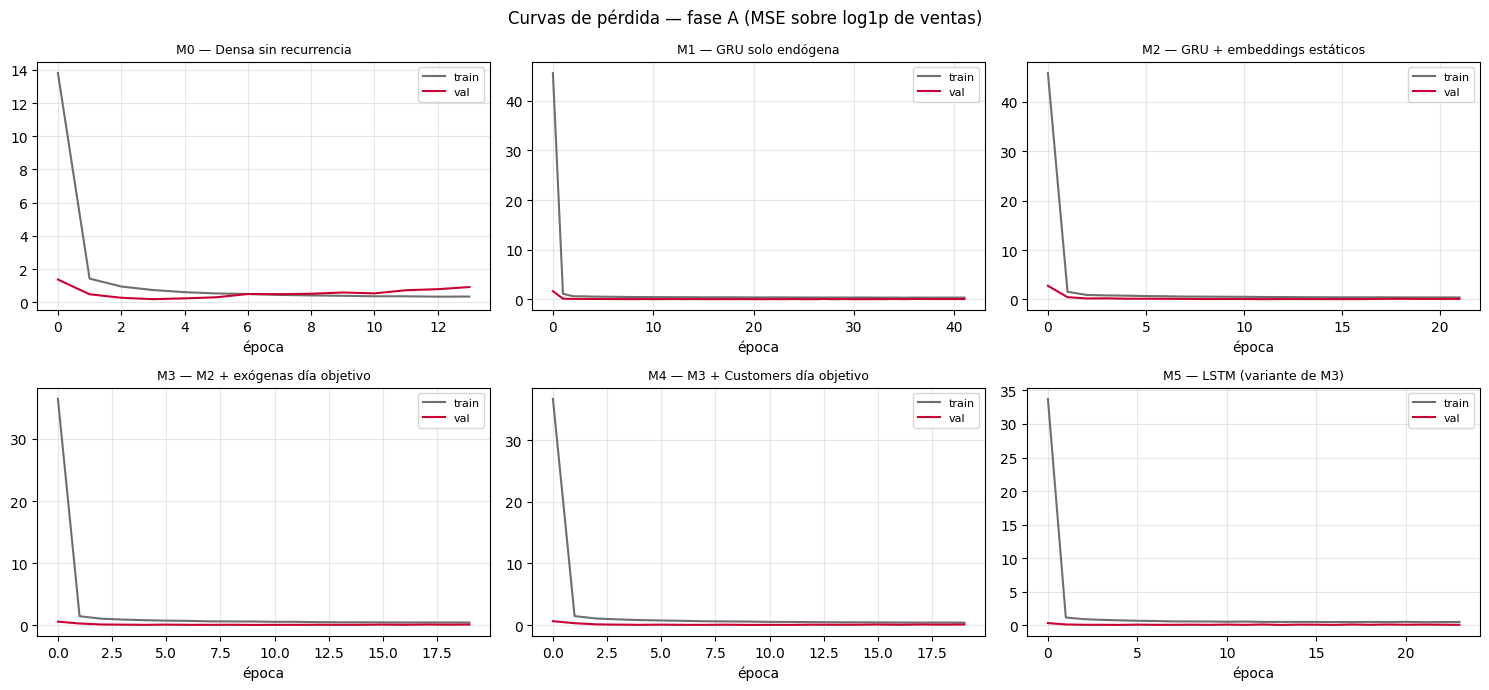

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (nombre, hist) in zip(axes.ravel(), historias_A.items()):
    ax.plot(hist.history["loss"], label="train", color=GRIS)
    ax.plot(hist.history["val_loss"], label="val", color=ROJO)
    ax.set_title(nombre, fontsize=9)
    ax.set_xlabel("época"); ax.legend(fontsize=8)
fig.suptitle("Curvas de pérdida — fase A (MSE sobre log1p de ventas)")
plt.tight_layout(); plt.show()

,modelo,R2_total,R2_abiertas,RMSE,MAE,epocas,minutos
0,M4 — M3 + Customers día objetivo,0.923,0.850,892.723,595.729,20,0.100
1,M3 — M2 + exógenas día objetivo,0.848,0.703,1255.857,889.450,20,0.100
2,M2 — GRU + embeddings estáticos,0.836,0.681,1301.004,883.664,22,0.100
3,M1 — GRU solo endógena,0.798,0.606,1445.741,1004.549,42,0.200
4,M5 — LSTM (variante de M3),0.756,0.524,1589.408,1127.191,24,0.100
5,M0 — Densa sin recurrencia,0.479,-0.017,2323.024,1757.971,14,0.000
6,Baseline persistente 7 días,0.475,-0.025,2331.453,1753.198,0,0.000
7,Baseline persistente 1 día,-0.047,-1.043,3291.641,1792.050,0,0.000


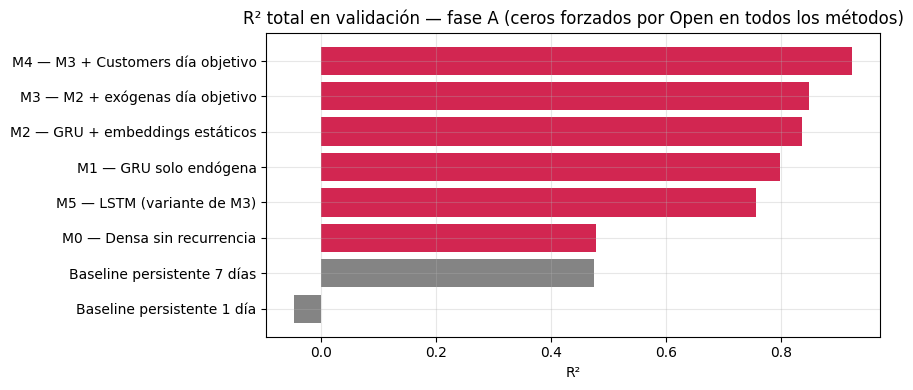

In [12]:
tabla_A = pd.DataFrame(filas_A).sort_values("R2_total", ascending=False).reset_index(drop=True)
display(tabla_A.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
orden = tabla_A.sort_values("R2_total")
colores = [ROJO if "M" == n[0] else GRIS for n in orden["modelo"]]
ax.barh(orden["modelo"], orden["R2_total"], color=colores, alpha=0.85)
ax.set_title("R² total en validación — fase A (ceros forzados por Open en todos los métodos)")
ax.set_xlabel("R²")
plt.tight_layout(); plt.show()

**Lectura de la fase A.** La progresión M1 → M2 → M3 aísla las dos aportaciones clave: los
*embeddings de tienda* (M2 sobre M1) y, sobre todo, las **exógenas del día objetivo** (M3 sobre
M2): sin ellas el modelo "no sabe qué día predice" y un baseline semanal lo supera, exactamente lo
que se observó en la primera versión del modelo del grupo. M4 mide cuánto añade `Customers` del
propio día (con su asterisco de *leakage*), y M5 confirma que GRU y LSTM rinden de forma muy
parecida en este problema (elegimos GRU por tener menos parámetros). Nota: estos R² no son
comparables 1:1 con la tabla de la sección 7 del notebook del grupo porque aquí el protocolo es
más exigente y realista (entrenamiento solo con días abiertos y ceros forzados en todos los
métodos).

## <font color='#CA3532'>**6. Fase B — modelo final (todas las tiendas, horizonte 14)**</font>

Se entrena la arquitectura ganadora con **las 1115 tiendas** y `horizonte = 14`, replicando la
tarea real del test (predecir el 2015-07-31 con datos hasta el 2015-07-17). Usamos la **arquitectura
ganadora** del barrido de arquitecturas (`entrenamiento_nocturno.py`): **GRU apilada 128+64**,
embedding de tienda de 32 dimensiones y densas 256→128→64, con `EarlyStopping`/`ReduceLROnPlateau`
generosos. Entrenamos las dos variantes finales: **sin** `Customers` (escenario realista) y **con**
`Customers` (máximo R², con discusión).

In [13]:
HORIZONTE_FINAL = 14
tiendas_fase_b = tiendas_dev if MODO_RAPIDO else None
EPOCHS_B = 3 if MODO_RAPIDO else 200

t0 = time.time()
VB = construir_ventanas(train_full, lookback=LOOKBACK, horizonte=HORIZONTE_FINAL,
                        tiendas=tiendas_fase_b)
print(f"ventanas fase B: {len(VB['y']):,} (descartadas por huecos: {VB['descartadas']:,}) "
      f"| construidas en {(time.time()-t0)/60:.1f} min "
      f"| memoria Xt: {VB['Xt'].nbytes/1e9:.2f} GB")
D_B = preparar_datos(VB)
del VB
gc.collect()

ventanas fase B: 948,504 (descartadas por huecos: 7,380) | construidas en 0.0 min | memoria Xt: 1.38 GB


corte train/val: 2015-06-05 | fit (abiertos): 746,946 | val (completa): 46,830


582

In [14]:
filas_B = []

fila, _ = baseline_persistencia(D_B, 14, "Baseline persistente 14 días (mismo día semana)")
filas_B.append(fila)

# Arquitectura ganadora del barrido nocturno: GRU apilada 128+64, densas 256→128→64, emb tienda 32
cfg_M3_full = dict(capas_rnn=(128, 64), densas=(256, 128, 64), dropouts=(0.35, 0.25, 0.1),
                   usar_dia_objetivo=True, dim_emb_store=32)
cfg_M4_full = dict(capas_rnn=(128, 64), densas=(256, 128, 64), dropouts=(0.35, 0.25, 0.1),
                   usar_dia_objetivo=True, usar_customers=True, dim_emb_store=32)

modelo_sin, hist_sin, fila_sin, pred_val_sin = ejecutar_experimento(
    "GRU final SIN Customers (realista)", cfg_M3_full, D_B,
    epochs=EPOCHS_B, batch=512, paciencia=25, verbose=2)
filas_B.append(fila_sin)

Epoch 1/200


1459/1459 - 71s - 49ms/step - loss: 1.3825 - mae: 0.8044 - val_loss: 0.7904 - val_mae: 0.8690 - learning_rate: 0.0010


Epoch 2/200


1459/1459 - 73s - 50ms/step - loss: 0.4891 - mae: 0.5524 - val_loss: 0.2262 - val_mae: 0.4502 - learning_rate: 0.0010


Epoch 3/200


...

Epoch 34/200


1459/1459 - 68s - 46ms/step - loss: 0.0116 - mae: 0.0714 - val_loss: 0.0194 - val_mae: 0.1052 - learning_rate: 2.5000e-04


Epoch 35/200


1459/1459 - 68s - 46ms/step - loss: 0.0116 - mae: 0.0710 - val_loss: 0.0197 - val_mae: 0.1065 - learning_rate: 2.5000e-04


GRU final SIN Customers (realista):  R2_total=0.935 | R2_abiertas=0.887 | 35 épocas | 41.2 min


In [15]:
modelo_con, hist_con, fila_con, pred_val_con = ejecutar_experimento(
    "GRU final CON Customers (máximo R²)", cfg_M4_full, D_B,
    epochs=EPOCHS_B, batch=512, paciencia=25, verbose=2)
filas_B.append(fila_con)

Epoch 1/200


1459/1459 - 70s - 48ms/step - loss: 1.3577 - mae: 0.7953 - val_loss: 0.0854 - val_mae: 0.2773 - learning_rate: 0.0010


Epoch 2/200


1459/1459 - 68s - 46ms/step - loss: 0.4394 - mae: 0.5262 - val_loss: 0.0133 - val_mae: 0.0951 - learning_rate: 0.0010


Epoch 3/200


...

Epoch 34/200


1459/1459 - 68s - 46ms/step - loss: 0.0038 - mae: 0.0458 - val_loss: 0.0072 - val_mae: 0.0684 - learning_rate: 2.5000e-04


Epoch 35/200


1459/1459 - 68s - 46ms/step - loss: 0.0039 - mae: 0.0457 - val_loss: 0.0068 - val_mae: 0.0654 - learning_rate: 2.5000e-04


GRU final CON Customers (máximo R²):  R2_total=0.979 | R2_abiertas=0.964 | 35 épocas | 39.6 min


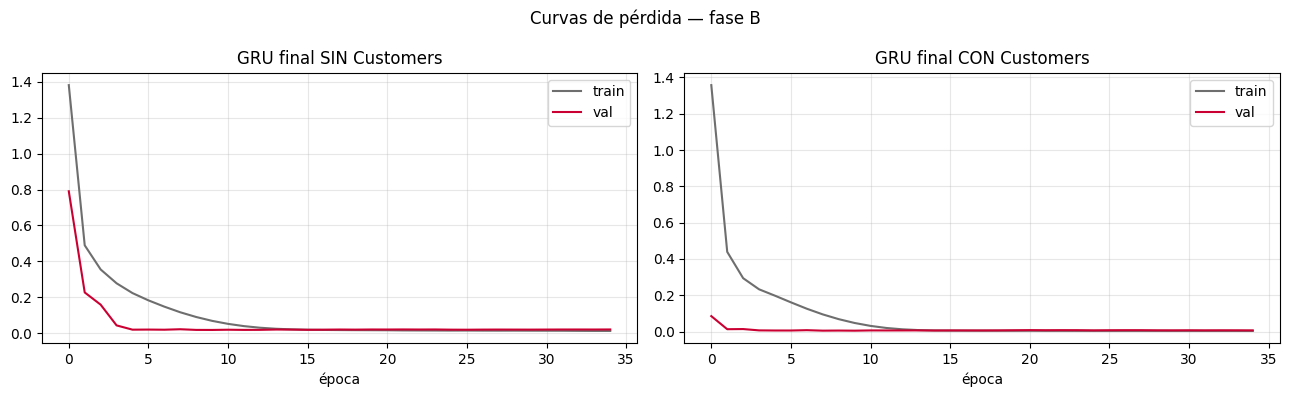

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (titulo, hist) in zip(axes, [("SIN Customers", hist_sin), ("CON Customers", hist_con)]):
    ax.plot(hist.history["loss"], label="train", color=GRIS)
    ax.plot(hist.history["val_loss"], label="val", color=ROJO)
    ax.set_title(f"GRU final {titulo}"); ax.set_xlabel("época"); ax.legend()
fig.suptitle("Curvas de pérdida — fase B")
plt.tight_layout(); plt.show()

In [17]:
# Métricas restringidas a las 10 tiendas de desarrollo (referencia a "las 10 tiendas" del enunciado)
mask10 = D_B["meta_val"]["Store"].isin(tiendas_dev).to_numpy()
for nombre, pred in [("GRU final SIN Customers — solo 10 tiendas dev", pred_val_sin),
                     ("GRU final CON Customers — solo 10 tiendas dev", pred_val_con)]:
    fila = fila_metricas(nombre, D_B["y_val"][mask10], pred[mask10], D_B["open_val"][mask10])
    fila["epocas"], fila["minutos"] = "-", "-"
    filas_B.append(fila)

tabla_B = pd.DataFrame(filas_B).reset_index(drop=True)
display(tabla_B.round(3))

mejor_es_con = fila_con["R2_total"] >= fila_sin["R2_total"]
mejor_modelo  = modelo_con if mejor_es_con else modelo_sin
mejor_cfg     = cfg_M4_full if mejor_es_con else cfg_M3_full
mejor_nombre  = fila_con["modelo"] if mejor_es_con else fila_sin["modelo"]
mejor_pred_val = pred_val_con if mejor_es_con else pred_val_sin
print(f"\nModelo seleccionado para la entrega: {mejor_nombre}")

,modelo,R2_total,R2_abiertas,RMSE,MAE,epocas,minutos
0,Baseline persistente 14 días (mismo día semana),0.770,0.601,1783.595,947.503,0,0.000
1,GRU final SIN Customers (realista),0.935,0.887,949.098,582.668,35,41.200
2,GRU final CON Customers (máximo R²),0.979,0.964,536.424,336.750,35,39.600
3,GRU final SIN Customers — solo 10 tiendas dev,0.945,0.893,753.136,502.359,-,-
4,GRU final CON Customers — solo 10 tiendas dev,0.969,0.940,563.563,339.464,-,-



Modelo seleccionado para la entrega: GRU final CON Customers (máximo R²)


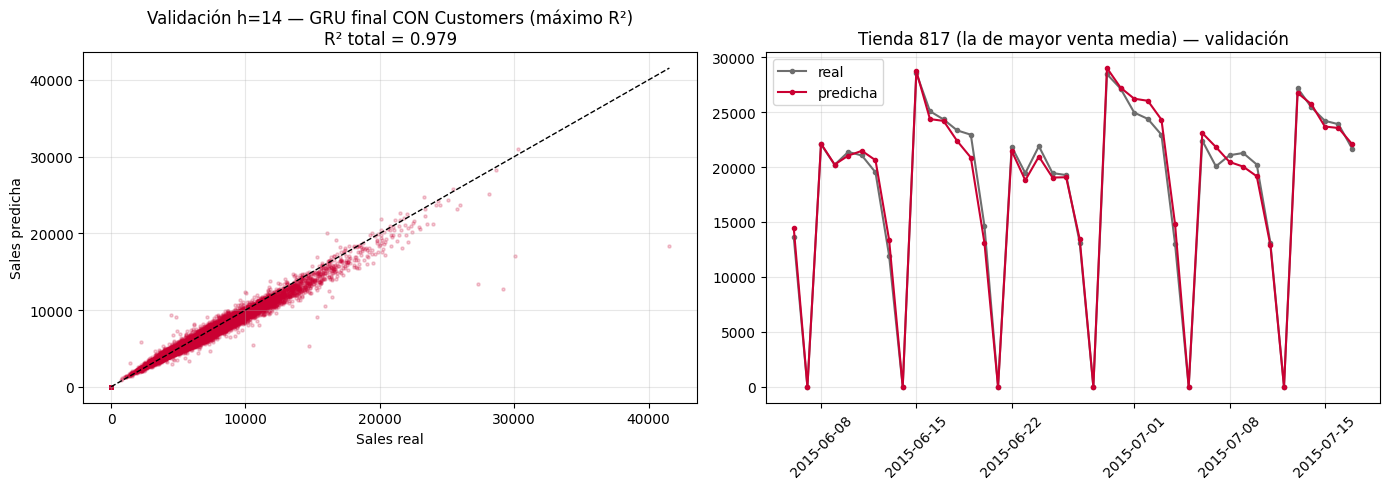

In [18]:
r2_mejor = r2_score(D_B["y_val"], mejor_pred_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
muestra = np.random.RandomState(7).choice(len(mejor_pred_val), size=min(15000, len(mejor_pred_val)),
                                          replace=False)
axes[0].scatter(D_B["y_val"][muestra], mejor_pred_val[muestra], s=5, alpha=0.2, color=ROJO)
lim = float(max(D_B["y_val"].max(), mejor_pred_val.max()))
axes[0].plot([0, lim], [0, lim], "k--", lw=1)
axes[0].set_xlabel("Sales real"); axes[0].set_ylabel("Sales predicha")
axes[0].set_title(f"Validación h=14 — {mejor_nombre}\nR² total = {r2_mejor:.3f}")

ventas_medias_tienda = train_full[train_full["Open"] == 1].groupby("Store")["Sales"].mean()
tienda_top = int(ventas_medias_tienda.idxmax())
mv = D_B["meta_val"].copy()
mv["real"], mv["pred"] = D_B["y_val"], mejor_pred_val
sub = mv[mv["Store"] == tienda_top].sort_values("DateObjetivo")
axes[1].plot(sub["DateObjetivo"], sub["real"], label="real", color=GRIS, marker="o", ms=3)
axes[1].plot(sub["DateObjetivo"], sub["pred"], label="predicha", color=ROJO, marker="o", ms=3)
axes[1].set_title(f"Tienda {tienda_top} (la de mayor venta media) — validación")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## <font color='#CA3532'>**7. Predicción final sobre `test.csv` (2015-07-31)**</font>

Para cada tienda se toma su **última ventana de 28 días** (hasta 2015-07-17) y las exógenas del
día objetivo se leen de `test.csv` (viernes, `Promo=1` en todas las tiendas). El hueco de 14 días
coincide exactamente con el horizonte de entrenamiento de la fase B. Tras predecir se fuerza
`Sales=0` en las tiendas cerradas y se guarda el fichero con el formato de `submission.csv`.

In [19]:
ultimas = train_full.sort_values(["Store", "Date"]).groupby("Store").tail(LOOKBACK)
conteo = ultimas.groupby("Store").size()
assert (conteo == LOOKBACK).all(), "Alguna tienda no tiene 28 días finales"

rangos = ultimas.groupby("Store")["Date"].agg(["min", "max"])
fecha_fin = train_full["Date"].max()
irregulares = rangos[(rangos["max"] != fecha_fin)
                     | ((rangos["max"] - rangos["min"]).dt.days != LOOKBACK - 1)]
print(f"tiendas con ventana final irregular: {len(irregulares)} de {len(rangos)}")

stores_orden = np.array(sorted(train_full["Store"].unique()))
assert (test_full["Store"].to_numpy() == stores_orden).all(), "Orden de tiendas no alineado con test"

Xt_test = ultimas[COLS_TEMPORALES].to_numpy(np.float32).reshape(len(stores_orden), LOOKBACK,
                                                                len(COLS_TEMPORALES))
Xe_test = test_full[COLS_ESTATICAS].to_numpy(np.float32)
doy_test = test_full["DayOfYear"].to_numpy(np.float32)
Xo_test = np.column_stack([
    test_full["DayOfWeekCode"].to_numpy(np.float32),
    test_full["StateHolidayCode"].to_numpy(np.float32),
    test_full["Promo"].to_numpy(np.float32),
    test_full["Open"].to_numpy(np.float32),
    test_full["SchoolHoliday"].to_numpy(np.float32),
    np.sin(2 * np.pi * doy_test / 365.25), np.cos(2 * np.pi * doy_test / 365.25),
    test_full["Customers"].to_numpy(np.float32),
]).astype(np.float32)

aplicar_escalado(D_B["params"], Xt_test, Xe_test, Xo_test)
open_test = test_full["Open"].to_numpy(np.float32)

pred_test_sin = predecir_real(modelo_sin, construir_xs(Xt_test, Xe_test, Xo_test, **cfg_M3_full), open_test)
pred_test_con = predecir_real(modelo_con, construir_xs(Xt_test, Xe_test, Xo_test, **cfg_M4_full), open_test)
pred_test_mejor = pred_test_con if mejor_es_con else pred_test_sin

print("\nDistribución de las predicciones para 2015-07-31:")
display(pd.DataFrame({"SIN Customers": pred_test_sin, "CON Customers": pred_test_con}).describe().round(1))

tiendas con ventana final irregular: 0 de 1115

Distribución de las predicciones para 2015-07-31:


,SIN Customers,CON Customers
count,1115.000,1115.000
mean,8158.000,8396.700
std,2390.500,2714.200
min,0.000,0.000
25%,6487.300,6516.200
50%,8023.100,8107.000
75%,9453.700,9726.800
max,20631.800,23703.600


guardado: submission_final.csv (1115 filas)
correlación con la submission de ejemplo: 0.993


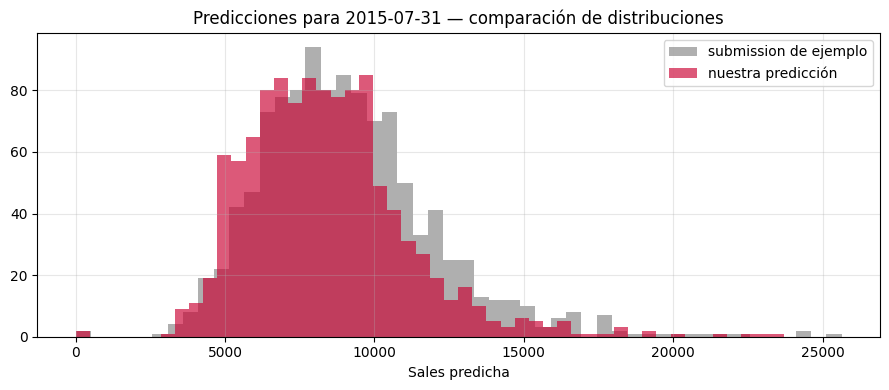

In [20]:
submission_final = pd.DataFrame({"Id": test_full["Id"].to_numpy(), "Sales": pred_test_mejor})

ruta_submission = "/tmp/submission_dry.csv" if MODO_RAPIDO else "submission_final.csv"
submission_final.to_csv(ruta_submission, index=False)
if not MODO_RAPIDO:
    mejor_modelo.save("mejor_modelo.keras")
print(f"guardado: {ruta_submission} ({len(submission_final)} filas)")

# Contraste con la submission de ejemplo del dataset (predicciones de un modelo de referencia)
comp = submission_final.merge(submission_ejemplo, on="Id", suffixes=("_nuestra", "_ejemplo"))
print(f"correlación con la submission de ejemplo: "
      f"{comp[['Sales_nuestra', 'Sales_ejemplo']].corr().iloc[0, 1]:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(comp["Sales_ejemplo"], bins=50, alpha=0.55, label="submission de ejemplo", color=GRIS)
ax.hist(comp["Sales_nuestra"], bins=50, alpha=0.65, label="nuestra predicción", color=ROJO)
ax.set_title("Predicciones para 2015-07-31 — comparación de distribuciones")
ax.set_xlabel("Sales predicha"); ax.legend()
plt.tight_layout(); plt.show()

## <font color='#CA3532'>**8. ¿Qué han aprendido los embeddings?**</font>

Si los embeddings capturan estructura real, tiendas con comportamiento similar deben quedar
próximas. Proyectamos el embedding de `Store` (24D) a 2D con PCA, coloreando por venta media, y
mostramos el embedding 2D de `StoreType` directamente.

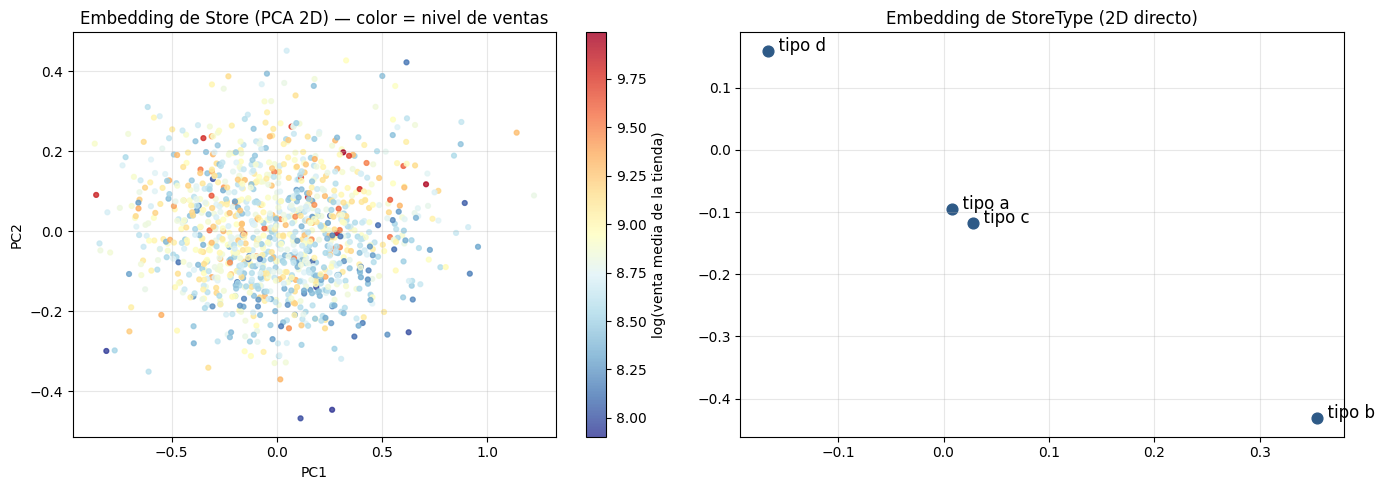

In [21]:
emb_store = mejor_modelo.get_layer("emb_store").get_weights()[0]
cats_store = categorias["Store"]
color_ventas = np.log1p([ventas_medias_tienda.get(int(s), 0.0) for s in cats_store])
proy = PCA(n_components=2, random_state=7).fit_transform(emb_store)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(proy[:, 0], proy[:, 1], c=color_ventas, cmap="RdYlBu_r", s=12, alpha=0.8)
fig.colorbar(sc, ax=axes[0], label="log(venta media de la tienda)")
axes[0].set_title("Embedding de Store (PCA 2D) — color = nivel de ventas")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

emb_st = mejor_modelo.get_layer("emb_storetype").get_weights()[0]
axes[1].scatter(emb_st[:, 0], emb_st[:, 1], color=AZUL, s=60)
for i, etiqueta in enumerate(categorias["StoreType"]):
    axes[1].annotate(f"  tipo {etiqueta}", (emb_st[i, 0], emb_st[i, 1]), fontsize=12)
axes[1].set_title("Embedding de StoreType (2D directo)")
plt.tight_layout(); plt.show()

## <font color='#CA3532'>**9. Resumen global de métricas**</font>

In [22]:
tabla_global = pd.concat([
    tabla_A.assign(fase="A — 10 tiendas, h=1"),
    tabla_B.assign(fase="B — todas las tiendas, h=14"),
], ignore_index=True)[["fase", "modelo", "R2_total", "R2_abiertas", "RMSE", "MAE"]]
display(tabla_global.round(3))

,fase,modelo,R2_total,R2_abiertas,RMSE,MAE
0,"A — 10 tiendas, h=1",M4 — M3 + Customers día objetivo,0.923,0.850,892.723,595.729
1,"A — 10 tiendas, h=1",M3 — M2 + exógenas día objetivo,0.848,0.703,1255.857,889.450
2,"A — 10 tiendas, h=1",M2 — GRU + embeddings estáticos,0.836,0.681,1301.004,883.664
3,"A — 10 tiendas, h=1",M1 — GRU solo endógena,0.798,0.606,1445.741,1004.549
4,"A — 10 tiendas, h=1",M5 — LSTM (variante de M3),0.756,0.524,1589.408,1127.191
5,"A — 10 tiendas, h=1",M0 — Densa sin recurrencia,0.479,-0.017,2323.024,1757.971
6,"A — 10 tiendas, h=1",Baseline persistente 7 días,0.475,-0.025,2331.453,1753.198
7,"A — 10 tiendas, h=1",Baseline persistente 1 día,-0.047,-1.043,3291.641,1792.050
8,"B — todas las tiendas, h=14",Baseline persistente 14 días (mismo día semana),0.770,0.601,1783.595,947.503
9,"B — todas las tiendas, h=14",GRU final SIN Customers (realista),0.935,0.887,949.098,582.668


## <font color='#CA3532'>**10. Reflexión final**</font>

**Qué entradas ayudaron más.** La progresión de la fase A lo cuantifica: la serie endógena sola
(M1) se queda lejos; los embeddings de tienda (M2) añaden la "identidad" de cada tienda; y el
salto grande llega con las **exógenas del día objetivo** (M3) — saber el día de la semana y si hay
promoción es más valioso que cualquier refinamiento de la arquitectura recurrente. Es la lección
central de las *entradas heterogéneas*: la ganancia no vino de apilar más capas, sino de dar al
modelo la información correcta por la rama correcta.

**Embeddings.** Aportan en dos planos: rendimiento (M2 > M1) e interpretabilidad — el embedding de
`Store` proyectado ordena las tiendas por nivel de venta sin que nadie se lo haya dicho, y el de
`StoreType` separa el tipo `b` (las 17 tiendas atípicas de venta alta) del resto.

**`Customers` y el *leakage*.** La variante con `Customers` del día objetivo mejora el R² (la
correlación ventas-clientes es 0,82), y `test.csv` la proporciona, por lo que es legítima *en esta
práctica*. Pero en un despliegue real el número de clientes del día a predecir no se conoce: por
eso entregamos las dos variantes y señalamos que la versión "sin Customers" es la estimación
honesta de rendimiento en producción. Una mejora intermedia sería predecir primero `Customers` y
encadenar ambos modelos.

**Decisiones de protocolo que importaron.** (1) Entrenar solo con días abiertos y forzar
`Sales=0` con `Open=0` convierte una fuente enorme de error en un acierto trivial — y es legítimo
porque `Open` es conocido. (2) Entrenar el modelo final a horizonte 14 alinea el entrenamiento con
la tarea real del test (hueco 2015-07-17 → 2015-07-31); un modelo a horizonte 1 estaría evaluándose
en condiciones que nunca vio. (3) Partición temporal estricta y escalado ajustado solo en train.

**Limitaciones.** El test oficial es un único día (viernes con `Promo=1` en todas las tiendas):
cualquier sesgo sistemático de ese día concreto domina el R² final, y no podemos medirlo
localmente porque `test.csv` no incluye las etiquetas. El enunciado menciona "las 10 tiendas"
mientras que `test.csv` trae 1115: reportamos también las métricas restringidas a las 10 tiendas
de desarrollo como referencia. Las ~181 tiendas con huecos de 2014 pierden las ventanas que
cruzan el hueco (descartadas explícitamente).

**Con más tiempo probaríamos:** búsqueda sistemática de hiperparámetros, *ensembles* de varias
semillas y horizontes, un modelo en dos etapas (clientes → ventas), validación cruzada temporal
con varios cortes, y mecanismos de atención sobre la ventana temporal.